<a href="https://colab.research.google.com/github/nishathakur05/100DaysOfCode/blob/main/aqi_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Loading the AQI dataset from the CSV file into a DataFrame

import pandas as pd
import numpy as np


file_path = "aqi_dataset.csv"
df = pd.read_csv(file_path)

df.head()


,datetime,date,year,month,day,hour,day_of_week,is_weekend,season,city,...,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,aqi_category
0,1/1/20 6:00,1/1/20,2020,1,1,6,Wednesday,0,winter,Delhi,...,119.6,47.7,5.19,12.3,9.4,100,3.6,1.2,500,Severe
1,1/1/20 6:00,1/1/20,2020,1,1,6,Wednesday,0,winter,Delhi,...,138.4,41.5,7.56,15.4,6.8,100,2.8,0.4,500,Severe
2,1/1/20 6:00,1/1/20,2020,1,1,6,Wednesday,0,winter,Delhi,...,121.5,42.4,4.76,14.3,6.1,100,4.2,1.0,500,Severe
3,1/1/20 6:00,1/1/20,2020,1,1,6,Wednesday,0,winter,Delhi,...,111.6,29.4,5.79,17.1,6.2,100,2.5,1.1,500,Severe
4,1/1/20 6:00,1/1/20,2020,1,1,6,Wednesday,0,winter,Delhi,...,115.2,30.3,5.01,24.8,7.6,100,3.6,2.2,500,Severe


In [ ]:
# Filtering the dataset for Gurugram Vikas Sadan and sorting them by datetime
vikas_sadan_df = df[df['station'] == 'Gurugram Vikas Sadan'].copy()

# Ensuring column names have no spaces
vikas_sadan_df.columns = vikas_sadan_df.columns.str.strip()

vikas_sadan_df['datetime'] = pd.to_datetime(
    vikas_sadan_df['datetime'],
    errors='coerce'
)
vikas_sadan_df = vikas_sadan_df.sort_values('datetime').reset_index(drop=True)

vikas_sadan_df.head()

/tmp/ipykernel_951/3279947028.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  vikas_sadan_df['datetime'] = pd.to_datetime(


,datetime,date,year,month,day,hour,day_of_week,is_weekend,season,city,...,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,aqi_category
0,2020-01-01 06:00:00,1/1/20,2020,1,1,6,Wednesday,0,winter,Gurugram,...,119.5,27.7,6.40,15.7,6.9,100,2.7,1.2,500,Severe
1,2020-01-01 12:00:00,1/1/20,2020,1,1,12,Wednesday,0,winter,Gurugram,...,97.0,17.7,3.02,28.9,20.7,55,6.2,1.3,435,Severe
2,2020-01-01 18:00:00,1/1/20,2020,1,1,18,Wednesday,0,winter,Gurugram,...,152.5,31.6,6.42,15.5,14.6,46,4.9,1.0,500,Severe
3,2020-01-01 23:00:00,1/1/20,2020,1,1,23,Wednesday,0,winter,Gurugram,...,100.0,27.9,4.66,24.3,12.4,54,6.2,1.6,470,Severe
4,2020-01-02 06:00:00,1/2/20,2020,1,2,6,Thursday,0,winter,Gurugram,...,134.2,26.8,5.33,15.2,9.6,100,4.1,1.4,500,Severe


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

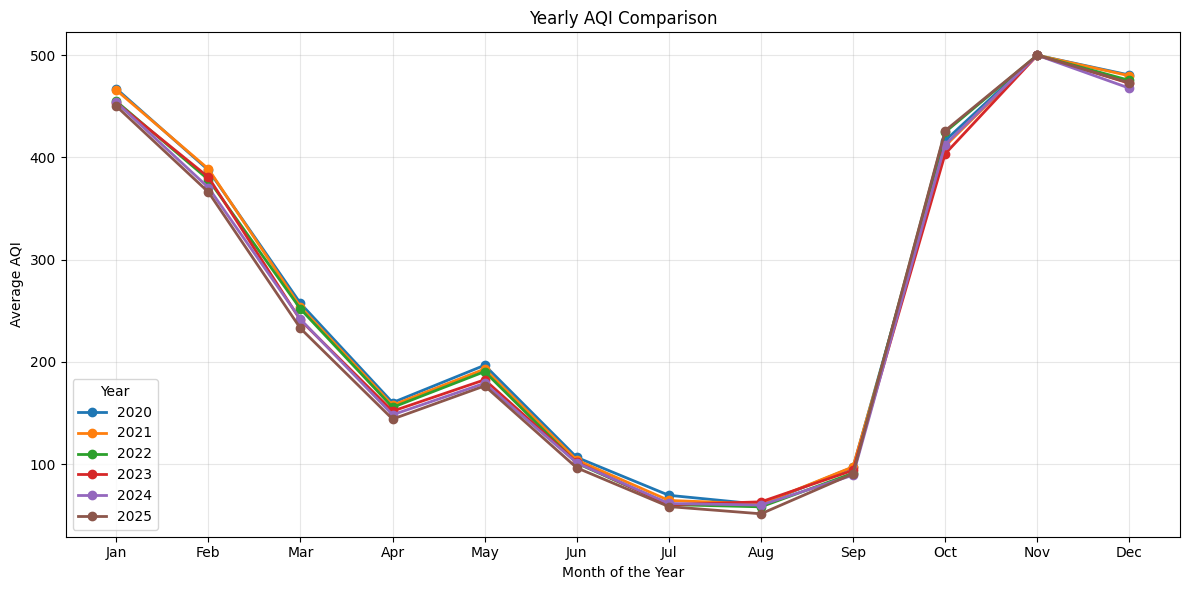

In [ ]:
# Add year and month columns
vikas_sadan_df['year'] = vikas_sadan_df['datetime'].dt.year
vikas_sadan_df['month'] = vikas_sadan_df['datetime'].dt.month

# Compute monthly average AQI for each year
yearly_trend = vikas_sadan_df.groupby(['year', 'month'])['aqi'].mean().unstack(level=0)

# Plot yearly monthly curves
plt.figure(figsize=(12, 6))
yearly_trend.plot(ax=plt.gca(), marker='o', linewidth=2)

plt.title("Yearly AQI Comparison")
plt.xlabel("Month of the Year")
plt.ylabel("Average AQI")
plt.xticks(
    range(1, 13),
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
)
plt.legend(title="Year")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


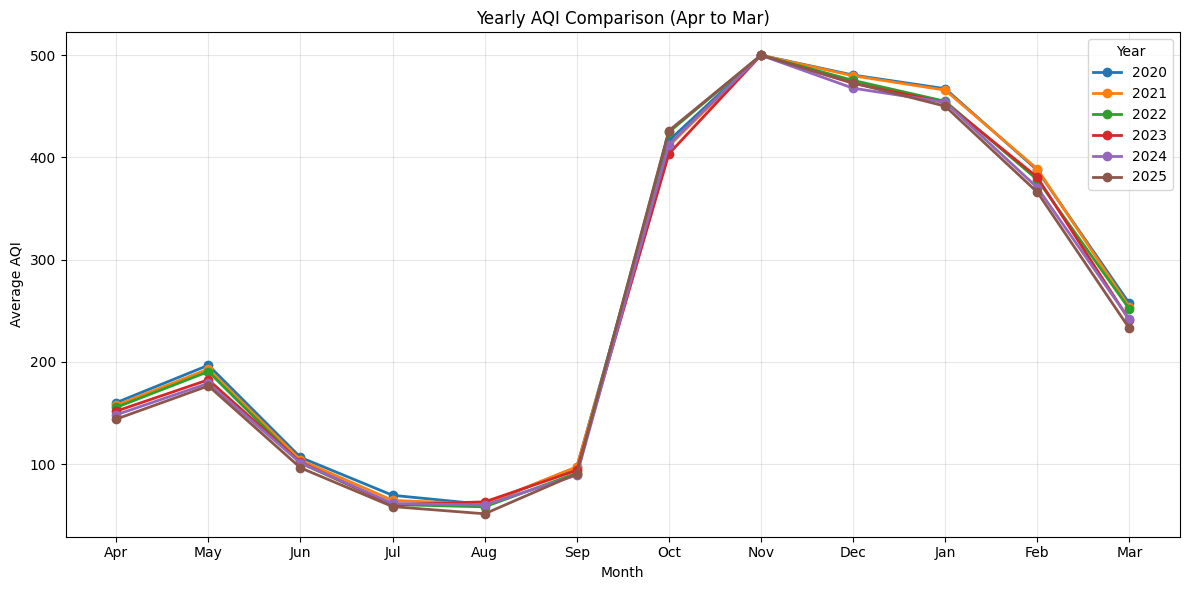

In [ ]:

# Get year and month name
vikas_sadan_df['year'] = vikas_sadan_df['datetime'].dt.year
vikas_sadan_df['month_name'] = vikas_sadan_df['datetime'].dt.strftime('%b')

# Apr to Mar order
month_order = ['Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar']

# Monthly average AQI by year
yearly_trend = (
    vikas_sadan_df
    .groupby(['month_name', 'year'])['aqi']
    .mean()
    .unstack('year')
    .reindex(month_order)
)

# Plot
plt.figure(figsize=(12, 6))
yearly_trend.plot(ax=plt.gca(), marker='o', linewidth=2)

plt.title("Yearly AQI Comparison (Apr to Mar)")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.xticks(range(len(month_order)), month_order)
plt.legend(title="Year")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


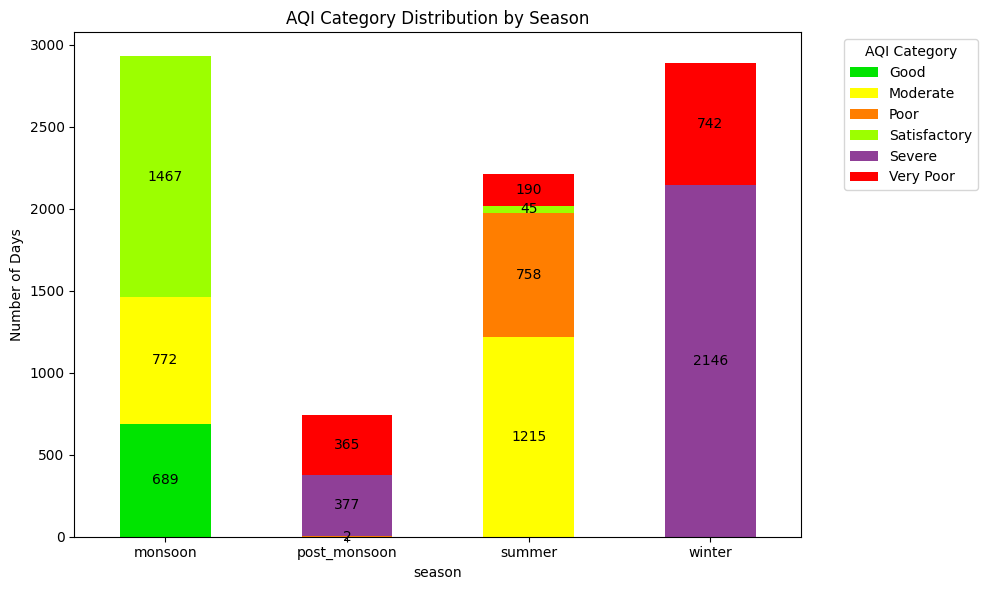

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Counting days per season and AQI category
season_category = vikas_sadan_df.groupby(['season','aqi_category']).size().unstack(fill_value=0)

# Using thh WHO Standard Color Scheme for AQI categories
aqi_colors = {
    'Good': '#00e400',         # Green
    'Satisfactory': '#9cff00', # Light green
    'Moderate': '#ffff00',     # Yellow
    'Poor': '#ff7e00',         # Orange
    'Very Poor': '#ff0000',    # Red
    'Severe': '#8f3f97'        # Purple
}

colors = [aqi_colors.get(cat, '#cccccc') for cat in season_category.columns]

# Plot stacked bar chart
ax = season_category.plot(kind='bar', stacked=True, figsize=(10,6), color=colors)

plt.ylabel('Number of Days')
plt.title('AQI Category Distribution by Season')
plt.xticks(rotation=0)
plt.legend(title='AQI Category', bbox_to_anchor=(1.05, 1), loc='upper left')

# Annotated counts on bars
for i, season in enumerate(season_category.index):
    y_bottom = 0
    for cat in season_category.columns:
        count = season_category.loc[season, cat]
        if count > 0:
            ax.text(i, y_bottom + count/2, str(count), ha='center', va='center', color='black', fontsize=10)
            y_bottom += count

plt.tight_layout()
plt.show()

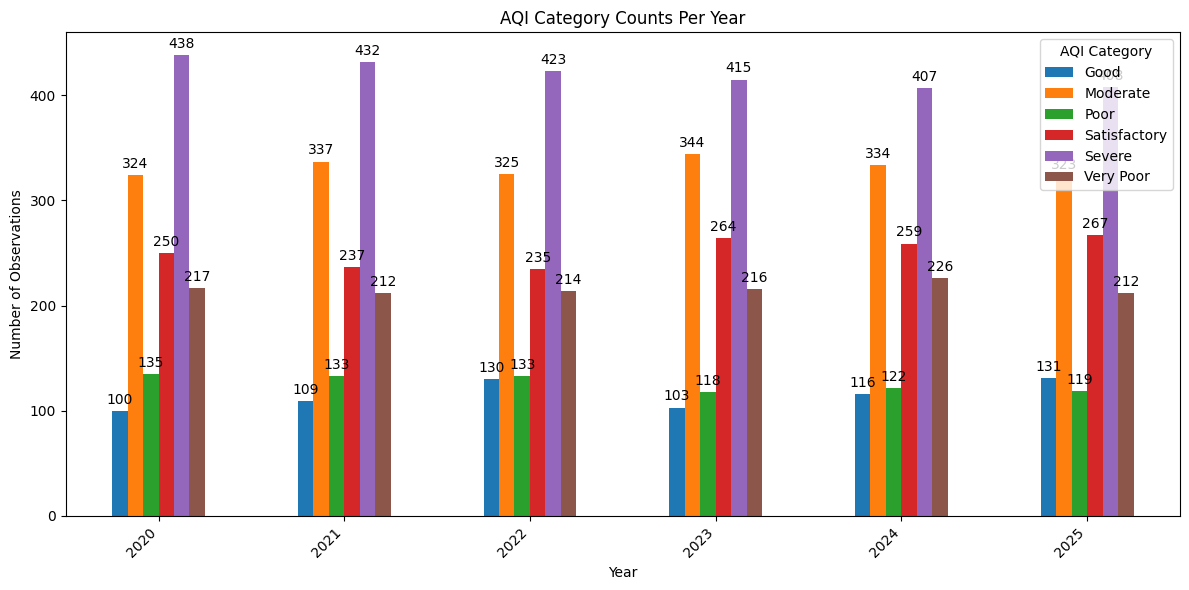

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure datetime is proper
vikas_sadan_df['datetime'] = pd.to_datetime(vikas_sadan_df['datetime'])
vikas_sadan_df['year'] = vikas_sadan_df['datetime'].dt.year

# Count of each AQI category per year
aqi_counts = (
    vikas_sadan_df.groupby(['year', 'aqi_category'])
    .size()
    .reset_index(name='count')
)

# Pivot for plotting
aqi_pivot = aqi_counts.pivot(index='year', columns='aqi_category', values='count').fillna(0)

# Plot grouped bar chart
ax = aqi_pivot.plot(kind='bar', figsize=(12,6))

plt.title("AQI Category Counts Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Observations")
plt.xticks(rotation=45, ha='right')  # Tilted x-axis labels
plt.legend(title="AQI Category")

# Annotate each bar with its value
for container in ax.containers:
    ax.bar_label(container, label_type='edge', fmt='%d', fontsize=10, padding=3)

plt.tight_layout()
plt.show()

In [ ]:
# Droping unnecessary columns from the dataframe
columns_to_drop = [
    'date', 'year', 'month', 'day', 'hour','day_of_week', 'season',
    'is_weekend', 'city', 'station', 'latitude', 'longitude'
]

vikas_sadan_df.drop(columns=columns_to_drop, inplace=True)

vikas_sadan_df.head()

,datetime,pm25,pm10,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,aqi_category,month_name
0,2020-01-01 06:00:00,385.0,703.0,119.5,27.7,6.40,15.7,6.9,100,2.7,1.2,500,Severe,Jan
1,2020-01-01 12:00:00,237.2,458.1,97.0,17.7,3.02,28.9,20.7,55,6.2,1.3,435,Severe,Jan
2,2020-01-01 18:00:00,306.6,515.3,152.5,31.6,6.42,15.5,14.6,46,4.9,1.0,500,Severe,Jan
3,2020-01-01 23:00:00,285.1,486.2,100.0,27.9,4.66,24.3,12.4,54,6.2,1.6,470,Severe,Jan
4,2020-01-02 06:00:00,355.1,585.4,134.2,26.8,5.33,15.2,9.6,100,4.1,1.4,500,Severe,Jan


In [ ]:
from tabulate import tabulate

# Select only the columns you want
selected_cols = [
    "datetime", "pm25", "pm10", "no2", "so2", "co", "o3",
    "temperature", "humidity", "wind_speed", "visibility", "aqi"
]

info_data = []
for col in selected_cols:
    sample_values = vikas_sadan_df[col].dropna().unique()[:4]
    sample_str = ", ".join(map(str, sample_values))
    info_data.append([
        col,
        vikas_sadan_df[col].dtype,
        vikas_sadan_df[col].isnull().sum(),
        vikas_sadan_df[col].nunique(),
        sample_str
    ])

print(tabulate(
    info_data,
    headers=['Column', 'Dtype', 'Missing', 'Unique', 'Sample'],
    tablefmt='fancy_grid'
))

╒═════════════╤════════════════╤═══════════╤══════════╤════════════════════════════════════════════════════════════════════════════════════╕
│ Column      │ Dtype          │   Missing │   Unique │ Sample                                                                             │
╞═════════════╪════════════════╪═══════════╪══════════╪════════════════════════════════════════════════════════════════════════════════════╡
│ datetime    │ datetime64[ns] │         0 │     8768 │ 2020-01-01 06:00:00, 2020-01-01 12:00:00, 2020-01-01 18:00:00, 2020-01-01 23:00:00 │
├─────────────┼────────────────┼───────────┼──────────┼────────────────────────────────────────────────────────────────────────────────────┤
│ pm25        │ float64        │         0 │     3330 │ 385.0, 237.2, 306.6, 285.1                                                         │
├─────────────┼────────────────┼───────────┼──────────┼────────────────────────────────────────────────────────────────────────────────────┤
│ pm10       

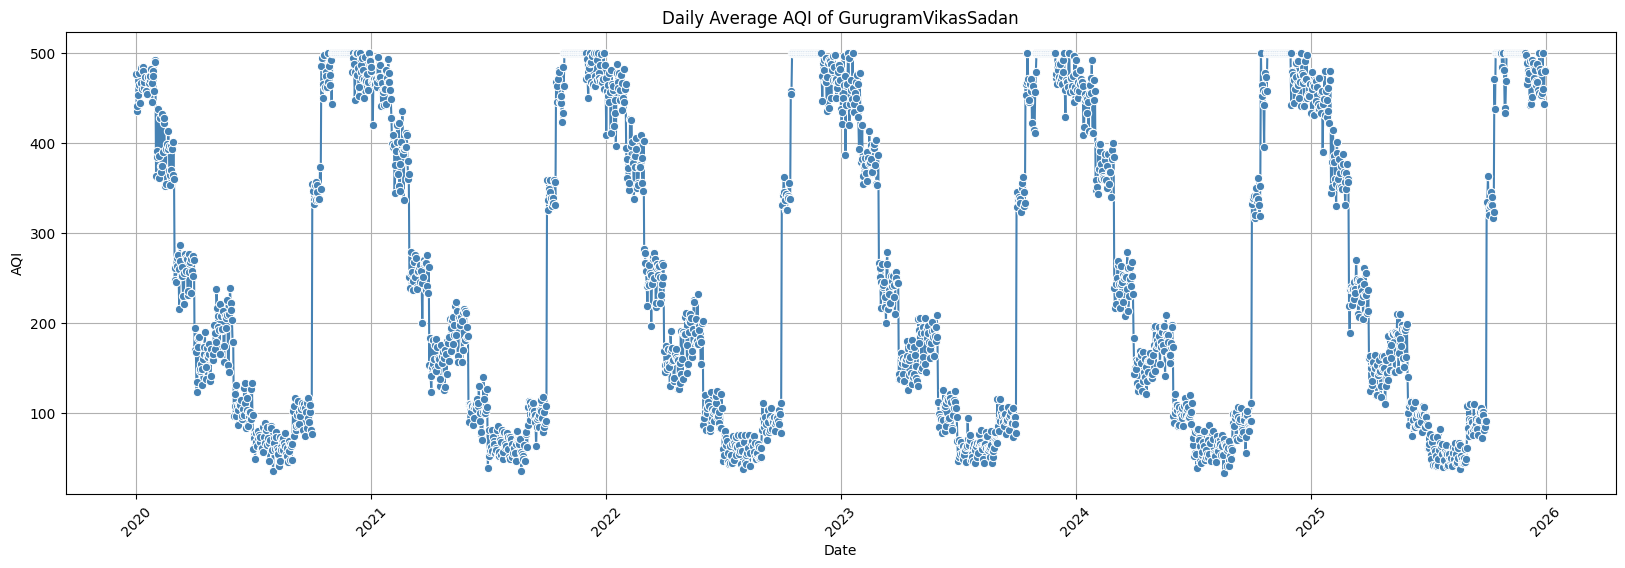

In [ ]:
# Extract date only
vikas_sadan_df['date'] = vikas_sadan_df['datetime'].dt.date

# Group by date and calculate daily average
daily_aqi = vikas_sadan_df.groupby('date')['aqi'].mean().reset_index()

# Plot
plt.figure(figsize=(20,6))
sns.lineplot(x='date', y='aqi', data=daily_aqi, marker='o', color='steelblue')
plt.title("Daily Average AQI of GurugramVikasSadan")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

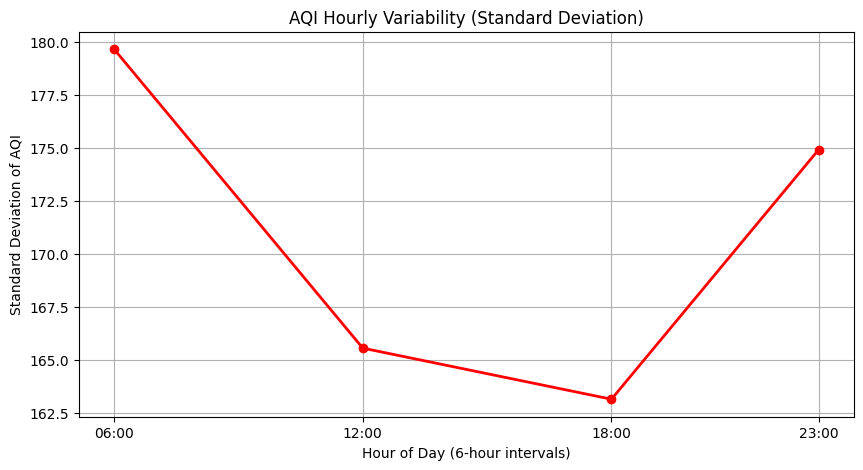


                 Hourly AQI Variability Summary (Standard Deviation):
        Most unpredictable hour     : 06:00 with Std Dev = 179.67
        Most predictable hour.      : 18:00 with Std Dev = 163.16



 Note: Standard deviation of AQI shows how much air quality fluctuates. Low SD is better, meaning stable and predictable air quality,
 while high SD indicates erratic, unpredictable, and potentially hazardous conditions.


In [ ]:

vikas_sadan_df['hour_slot'] = vikas_sadan_df['datetime'].dt.hour

hourly_std = vikas_sadan_df.groupby('hour_slot')['aqi'].std().reset_index()
hourly_std.rename(columns={'aqi':'std_dev'}, inplace=True)

# Plotting standard deviation only
plt.figure(figsize=(10,5))
plt.plot(hourly_std['hour_slot'], hourly_std['std_dev'], marker='o', color='red', linewidth=2)
plt.xticks(hourly_std['hour_slot'], [f"{h:02d}:00" for h in hourly_std['hour_slot']])
plt.xlabel("Hour of Day (6-hour intervals)")
plt.ylabel("Standard Deviation of AQI")
plt.title("AQI Hourly Variability (Standard Deviation)")
plt.grid(True)
plt.show()

# Print summary



max_std_hour = hourly_std.loc[hourly_std['std_dev'].idxmax()]
min_std_hour = hourly_std.loc[hourly_std['std_dev'].idxmin()]


print(f"""
        ======================================================================
                 Hourly AQI Variability Summary (Standard Deviation):
        ======================================================================
        Most unpredictable hour     : {int(max_std_hour['hour_slot']):02d}:00 with Std Dev = {max_std_hour['std_dev']:.2f}
        Most predictable hour.      : {int(min_std_hour['hour_slot']):02d}:00 with Std Dev = {min_std_hour['std_dev']:.2f}

""")


print("\n Note: Standard deviation of AQI shows how much air quality fluctuates. " \
"Low SD is better, meaning stable and predictable air quality,\n while high SD indicates erratic," \
" unpredictable, and potentially hazardous conditions.")


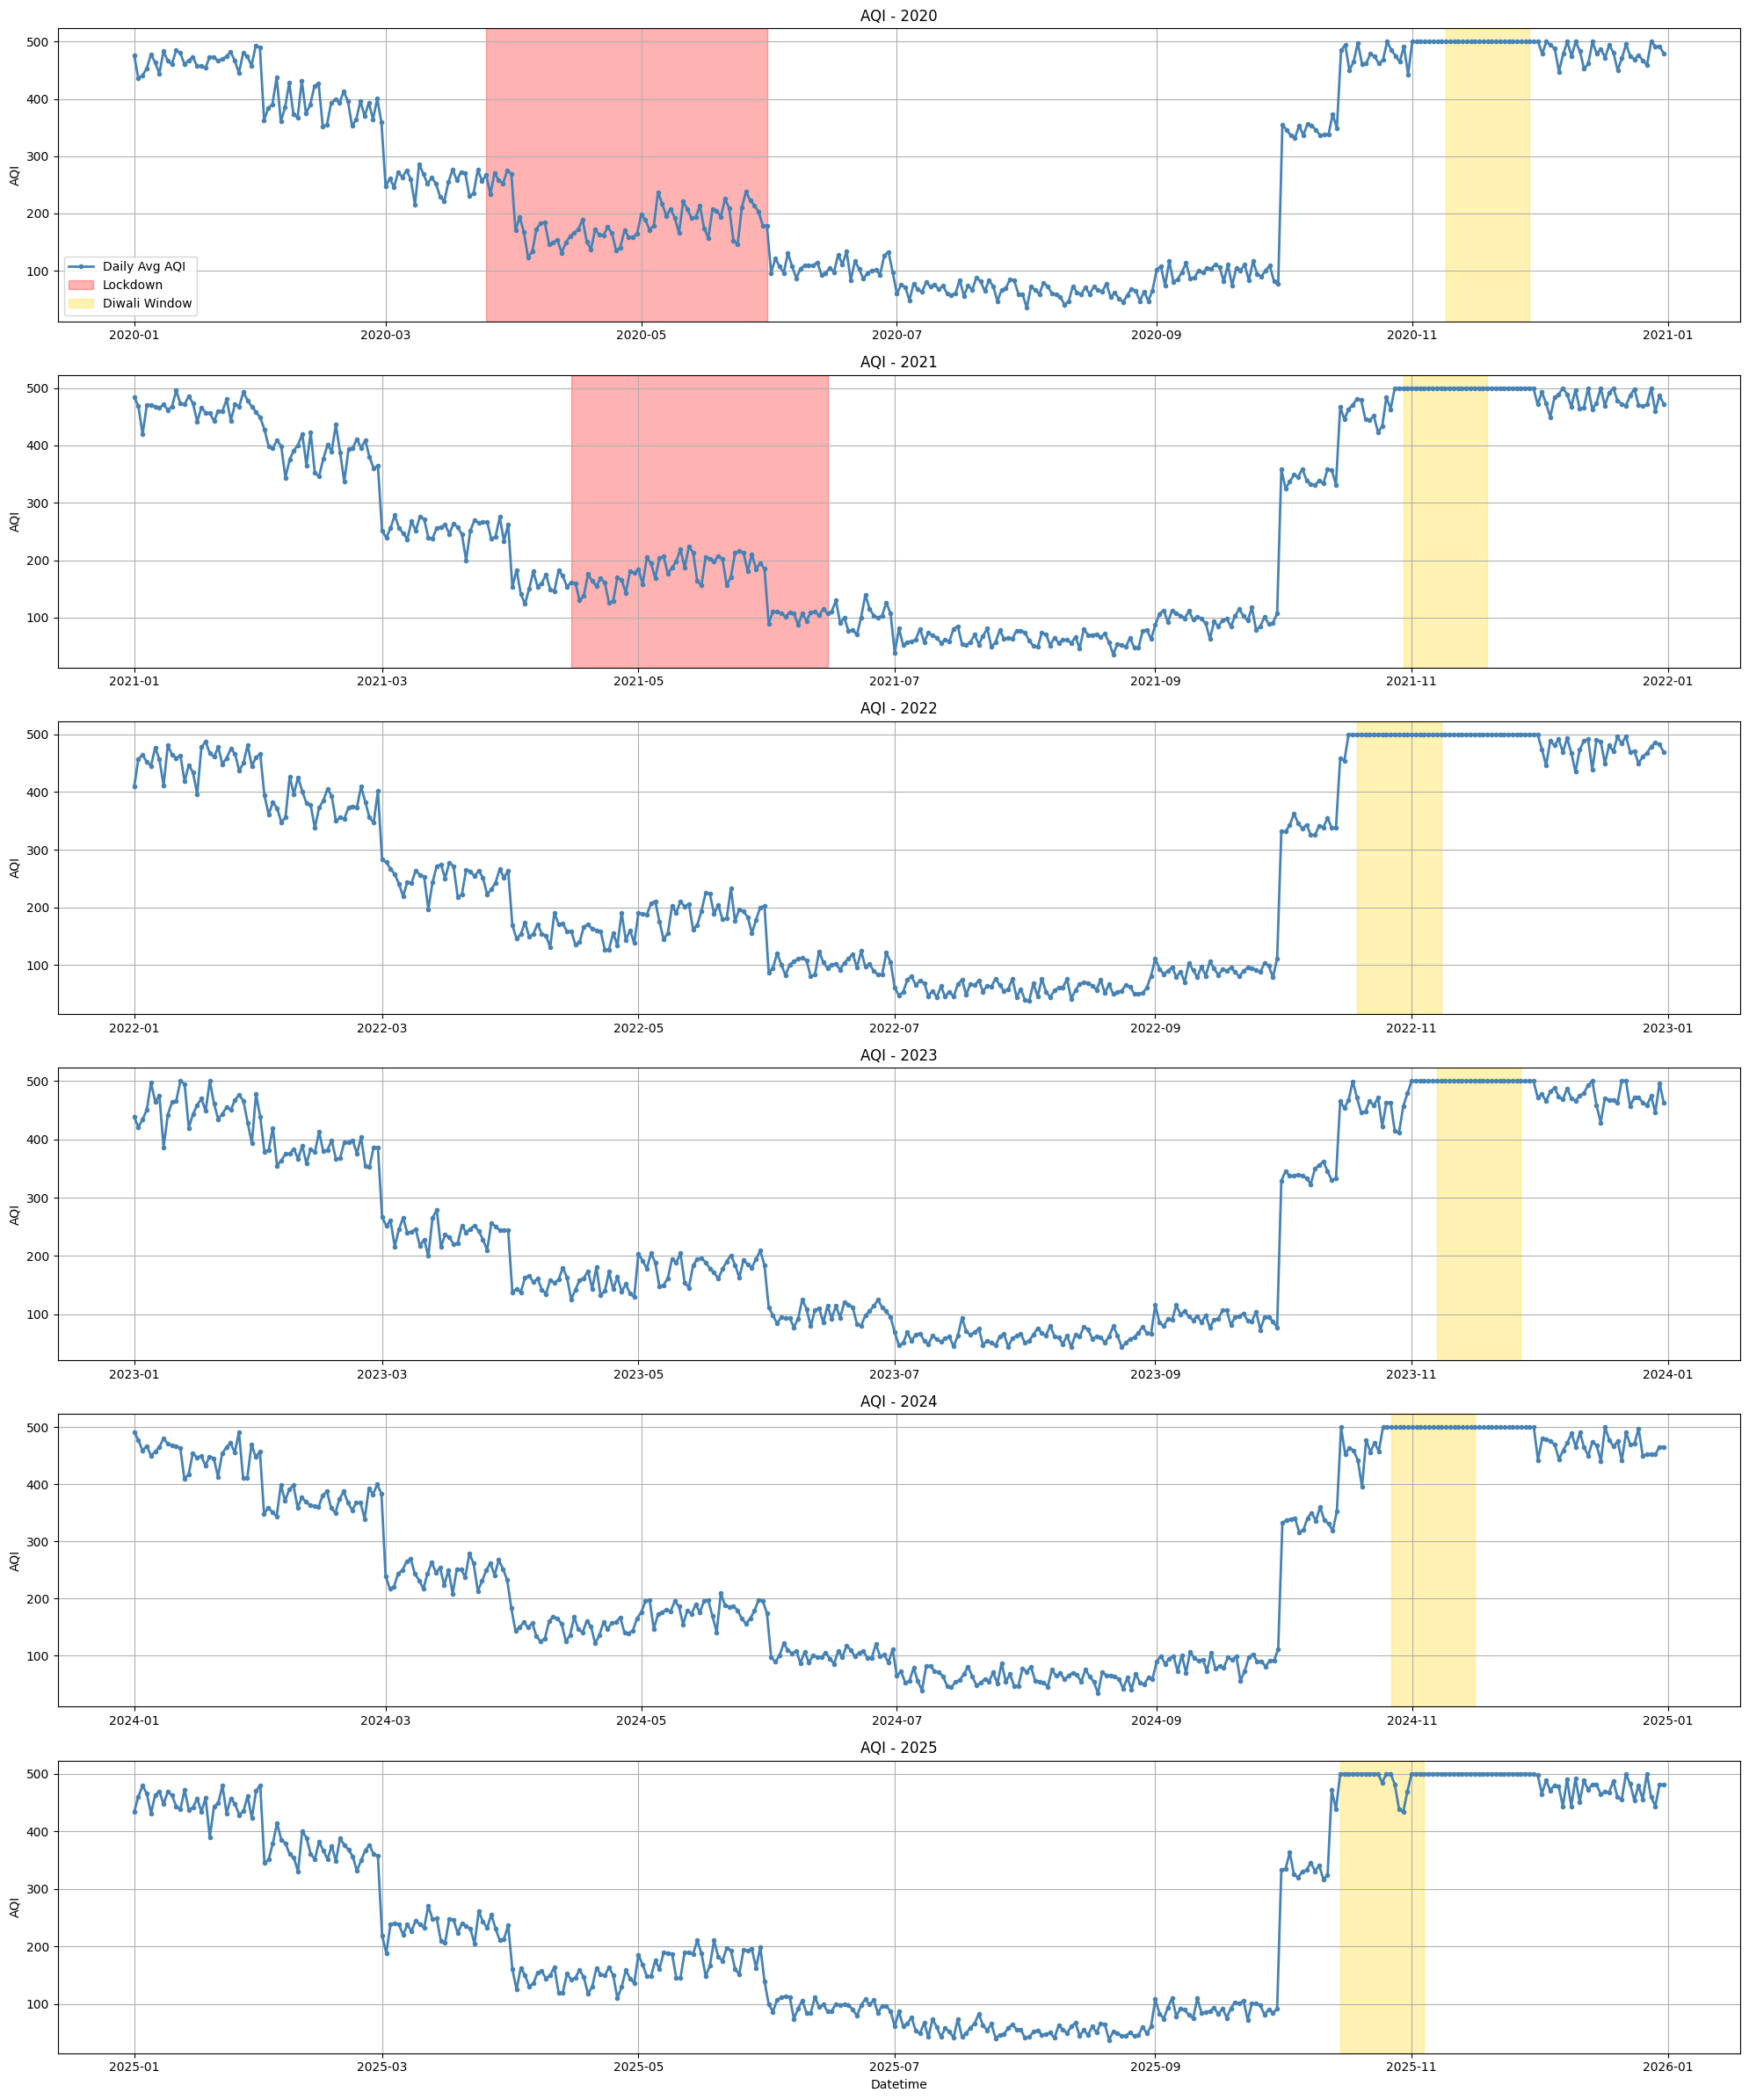

In [ ]:
# Creating year and date columns
vikas_sadan_df['year'] = vikas_sadan_df['datetime'].dt.year
vikas_sadan_df['date'] = vikas_sadan_df['datetime'].dt.date

daily_aqi_df = vikas_sadan_df.groupby('date')['aqi'].mean().reset_index()
daily_aqi_df['year'] = pd.to_datetime(daily_aqi_df['date']).dt.year


lockdowns = [
    (pd.to_datetime('2020-03-25'), pd.to_datetime('2020-05-31')),
    (pd.to_datetime('2021-04-15'), pd.to_datetime('2021-06-15'))
]

# Diwali periods (5 days before, 15 days after) — set manually
diwali_periods = [
    (pd.to_datetime('2020-11-09'), pd.to_datetime('2020-11-29')),
    (pd.to_datetime('2021-10-30'), pd.to_datetime('2021-11-19')),
    (pd.to_datetime('2022-10-19'), pd.to_datetime('2022-11-08')),
    (pd.to_datetime('2023-11-07'), pd.to_datetime('2023-11-27')),
    (pd.to_datetime('2024-10-27'), pd.to_datetime('2024-11-16')),
    (pd.to_datetime('2025-10-15'), pd.to_datetime('2025-11-04'))
]

years = sorted(daily_aqi_df['year'].unique())
num_years = len(years)

fig, axes = plt.subplots(num_years, 1, figsize=(20, 4*num_years), sharex=False)

for i, year in enumerate(years):

    year_daily = daily_aqi_df[daily_aqi_df['year'] == year]

    year_hourly = vikas_sadan_df[vikas_sadan_df['year'] == year]

    axes[i].plot(year_daily['date'], year_daily['aqi'], color='steelblue', linewidth=2, marker='o', markersize=3, label='Daily Avg AQI')

    # Shading lockdown periods if intersecting this year
    for start, end in lockdowns:
        if start.year <= year <= end.year:
            axes[i].axvspan(max(start, pd.Timestamp(year,1,1)),
                            min(end, pd.Timestamp(year,12,31)),
                            color='red', alpha=0.3, label='Lockdown' if i==0 else "")

        # Inside your for loop over years
    for start, end in diwali_periods:
        if start.year <= year <= end.year:
            axes[i].axvspan(max(start, pd.Timestamp(year,1,1)),
                            min(end, pd.Timestamp(year,12,31)),
                            color='gold', alpha=0.3,
                            label='Diwali Window' if i == 0 else "")

    axes[i].set_title(f"AQI - {year}")
    axes[i].set_ylabel("AQI")
    axes[i].grid(True)
    if i == 0:
        axes[i].legend()

axes[-1].set_xlabel("Datetime")
plt.tight_layout()
plt.show()



                 ╔══════════════════════════════════════════╗
                 ║      WEEKDAY vs WEEKEND MEAN AQI         ║
                 ╠══════════════════╦═══════════════════════╣
                 ║ Weekday          ║                264.74 ║
                 ║ Weekend          ║                249.66 ║
                 ╚══════════════════╩═══════════════════════╝



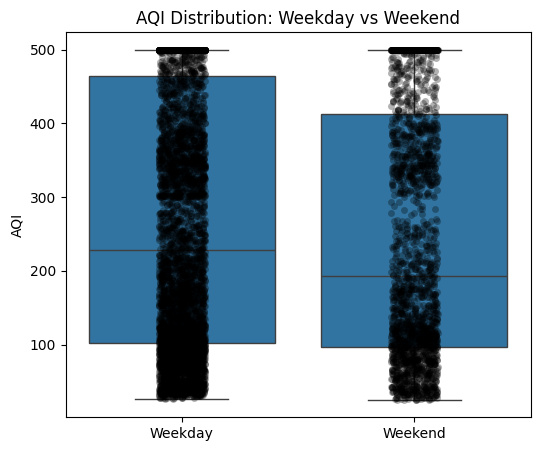

In [ ]:
weekend_labels = np.where(vikas_sadan_df['datetime'].dt.dayofweek.isin([5,6]), 'Weekend', 'Weekday')

# Calculate mean AQI for Weekday vs Weekend
mean_aqi = (
    pd.DataFrame({'Day Type': weekend_labels, 'AQI': vikas_sadan_df['aqi']})
    .groupby('Day Type', as_index=False)['AQI']
    .mean()
    .rename(columns={'AQI': 'Mean AQI'})
)

print("\n")
print("                 ╔══════════════════════════════════════════╗")
print("                 ║      WEEKDAY vs WEEKEND MEAN AQI         ║")
print("                 ╠══════════════════╦═══════════════════════╣")
for _, row in mean_aqi.iterrows():
    print(f"                 ║ {row['Day Type']:<16} ║ {row['Mean AQI']:>21.2f} ║")
print("                 ╚══════════════════╩═══════════════════════╝\n")


plt.figure(figsize=(6,5))

# Boxplot for AQI vs weekend label
sns.boxplot(
    x=np.where(vikas_sadan_df['datetime'].dt.dayofweek.isin([5,6]), 'Weekend', 'Weekday'),
    y=vikas_sadan_df['aqi']
)
# Overlay individual points
sns.stripplot(x=weekend_labels , y='aqi', data=vikas_sadan_df, color='black', alpha=0.3, jitter=True)

plt.ylabel('AQI')
plt.title('AQI Distribution: Weekday vs Weekend')
plt.show()

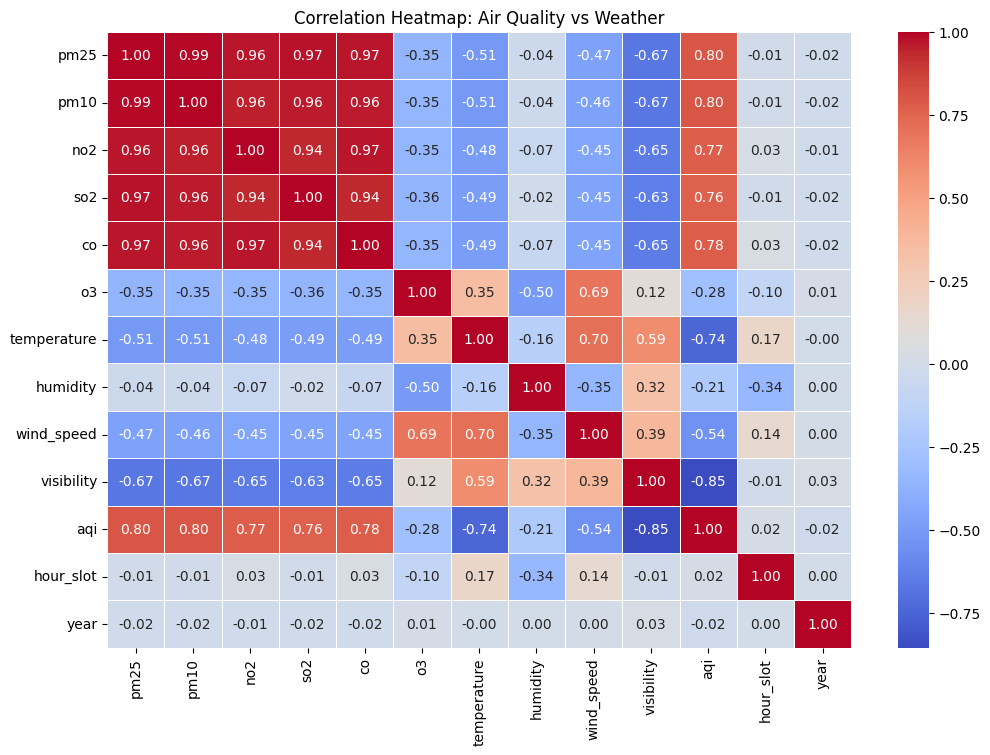

In [ ]:
numeric_vikas_sadan_df = vikas_sadan_df.select_dtypes(include=['number'])

# Calculating the correlation matrix
corr_matrix = numeric_vikas_sadan_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap: Air Quality vs Weather")
plt.show()

In [ ]:
# humidity, 03 and wind speed are the least corelated features with AQI. So, We will drop them and update the dataframe.

low_corr_column = ['humidity', 'wind_speed', 'o3']

vikas_sadan_df.drop(columns=low_corr_column, inplace=True)

vikas_sadan_df.reset_index(drop=True, inplace=True)

vikas_sadan_df.head()

,datetime,pm25,pm10,no2,so2,co,temperature,visibility,aqi,aqi_category,month_name,date,hour_slot,year
0,2020-01-01 06:00:00,385.0,703.0,119.5,27.7,6.40,6.9,1.2,500,Severe,Jan,2020-01-01,6,2020
1,2020-01-01 12:00:00,237.2,458.1,97.0,17.7,3.02,20.7,1.3,435,Severe,Jan,2020-01-01,12,2020
2,2020-01-01 18:00:00,306.6,515.3,152.5,31.6,6.42,14.6,1.0,500,Severe,Jan,2020-01-01,18,2020
3,2020-01-01 23:00:00,285.1,486.2,100.0,27.9,4.66,12.4,1.6,470,Severe,Jan,2020-01-01,23,2020
4,2020-01-02 06:00:00,355.1,585.4,134.2,26.8,5.33,9.6,1.4,500,Severe,Jan,2020-01-02,6,2020


In [ ]:
# Round everything to the nearest 6-hour frequency ('6H')
# Rounding can push late 2025 timestamps into 2026
vikas_sadan_df['datetime'] = vikas_sadan_df['datetime'].dt.round('6h')

# Filter to keep only 2025 and earlier
vikas_sadan_df = vikas_sadan_df[vikas_sadan_df['datetime'].dt.year < 2026]

# Now check the gaps again
vikas_sadan_df['is_6hrs'] = vikas_sadan_df['datetime'].diff() == pd.Timedelta(hours=6)
formatted_check = pd.DataFrame({
    "Date": vikas_sadan_df['datetime'].dt.date,
    "Time": vikas_sadan_df['datetime'].dt.time,
    "6-Hour Gap Valid?": np.where(vikas_sadan_df['is_6hrs'], "Valid", "Invalid")
})

print(formatted_check.head(10))

valid_count = vikas_sadan_df['is_6hrs'].sum()
invalid_count = (~vikas_sadan_df['is_6hrs']).sum()

print(f"""
        ===================================
                6-Hour Gaps Summary
        ===================================
        Valid gaps   : {valid_count}
        Invalid gaps : {invalid_count}
""")

if invalid_count == 1:
    print("Note: first row can be invalid because it is the starting row.")


         Date      Time 6-Hour Gap Valid?
0  2020-01-01  06:00:00           Invalid
1  2020-01-01  12:00:00             Valid
2  2020-01-01  18:00:00             Valid
3  2020-01-02  00:00:00             Valid
4  2020-01-02  06:00:00             Valid
5  2020-01-02  12:00:00             Valid
6  2020-01-02  18:00:00             Valid
7  2020-01-03  00:00:00             Valid
8  2020-01-03  06:00:00             Valid
9  2020-01-03  12:00:00             Valid

                6-Hour Gaps Summary
        Valid gaps   : 8766
        Invalid gaps : 1

Note: first row can be invalid because it is the starting row.


In [ ]:
print("Dropping derived columns (created earlier for analysis). They are not needed for train/test.")

vikas_sadan_df = vikas_sadan_df.drop(
    columns=['aqi_category', 'month_name', 'date', 'hour_slot', 'year'],
    errors='ignore'
)

Dropping derived columns (created earlier for analysis). They are not needed for train/test.


In [ ]:
from tabulate import tabulate

info_data = []

for col in vikas_sadan_df.columns:

    # Take 5 non-null sample values
    sample_values = vikas_sadan_df[col].dropna().head(5).tolist()
    sample_str = ", ".join(map(str, sample_values))

    info_data.append([
        col,
        vikas_sadan_df[col].dtype,
        vikas_sadan_df[col].isnull().sum(),
        vikas_sadan_df[col].nunique(),
        sample_str
    ])

print(tabulate(
    info_data,
    headers=['Column', 'Dtype', 'Missing', 'Unique', 'Sample Values'],
    tablefmt='fancy_grid'
))

╒═════════════╤════════════════╤═══════════╤══════════╤═════════════════════════════════════════════════════════════════════════════════════════════════════════╕
│ Column      │ Dtype          │   Missing │   Unique │ Sample Values                                                                                           │
╞═════════════╪════════════════╪═══════════╪══════════╪═════════════════════════════════════════════════════════════════════════════════════════════════════════╡
│ datetime    │ datetime64[ns] │         0 │     8767 │ 2020-01-01 06:00:00, 2020-01-01 12:00:00, 2020-01-01 18:00:00, 2020-01-02 00:00:00, 2020-01-02 06:00:00 │
├─────────────┼────────────────┼───────────┼──────────┼─────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ pm25        │ float64        │         0 │     3329 │ 385.0, 237.2, 306.6, 285.1, 355.1                                                                       │
├─────────────┼─────────────

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:
# Features (X): Drop the target and all non-numeric columns
X = vikas_sadan_df.drop(columns=['aqi', 'datetime'])

# Target (y): This is what we want to predict
y = vikas_sadan_df['aqi']

# Check what columns are left in X
print("Features being used:", X.columns.tolist(),"\n")
print("[DF] X-shape:", X.shape, "\n[DF] y-shape:", y.shape)

Features being used: ['pm25', 'pm10', 'no2', 'so2', 'co', 'temperature', 'visibility', 'is_6hrs'] 

[DF] X-shape: (8767, 8) 
[DF] y-shape: (8767,)


In [ ]:
look_back = 12    # past 12 rows (3 days)
look_ahead = 3    # next 3 rows (1 day)
target_col = 'aqi'

# --------------------------
# Create sliding windows
# --------------------------
values = vikas_sadan_df[target_col].values
X, y = [], []

for i in range(len(values) - look_back - look_ahead + 1):
    X.append(values[i:i+look_back])
    y.append(values[i+look_back:i+look_back+look_ahead])

X = np.array(X)  # shape: (samples, look_back)
y = np.array(y)  # shape: (samples, look_ahead)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (8753, 12)
y shape: (8753, 3)


In [ ]:
# Define train-test split index (e.g., 80% train, 20% test)
split_index = int(len(X) * 0.8)

# Use standard NumPy slicing
X_train = X[:split_index]
X_test  = X[split_index:]
y_train = y[:split_index]
y_test  = y[split_index:]

In [ ]:
# Scaling
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)


In [ ]:
# Training Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train_scaled)

# Predict on test set
y_test_pred_scaled = lr_model.predict(X_test_scaled)

# Convert predictions back to original AQI scale
y_test_pred  = scaler_y.inverse_transform(y_test_pred_scaled)
y_test_orig  = scaler_y.inverse_transform(y_test_scaled)

# Compute test metrics
lg_mse = mean_squared_error(y_test_orig, y_test_pred)
lg_rmse = np.sqrt(lg_mse)
lg_mae  = np.mean(np.abs(y_test_orig - y_test_pred))
lg_r2   = r2_score(y_test_orig, y_test_pred)



print( "                        ╔══════════════════════════════════════════╗")
print( "                        ║   LINEAR REGRESSION EVALUATION METRICS   ║")
print( "                        ╠══════════════════════════════════════════╣")
print(f"                        ║  RMSE: {lg_rmse:>30.6f}    ║")
print( "                        ╠══════════════════════════════════════════╣")
print(f"                        ║  MSE:  {lg_mse:>30.6f}    ║")
print( "                        ╠══════════════════════════════════════════╣")
print(f"                        ║  MAE:  {lg_mae:>30.6f}    ║")
print( "                        ╠══════════════════════════════════════════╣")
print(f"                        ║  R²:   {lg_r2:>30.6f}    ║")
print( "                        ╚══════════════════════════════════════════╝")


                        ╔══════════════════════════════════════════╗
                        ║   LINEAR REGRESSION EVALUATION METRICS   ║
                        ╠══════════════════════════════════════════╣
                        ║  RMSE:                      36.483431    ║
                        ╠══════════════════════════════════════════╣
                        ║  MSE:                     1331.040768    ║
                        ╠══════════════════════════════════════════╣
                        ║  MAE:                       24.961341    ║
                        ╠══════════════════════════════════════════╣
                        ║  R²:                         0.959038    ║
                        ╚══════════════════════════════════════════╝


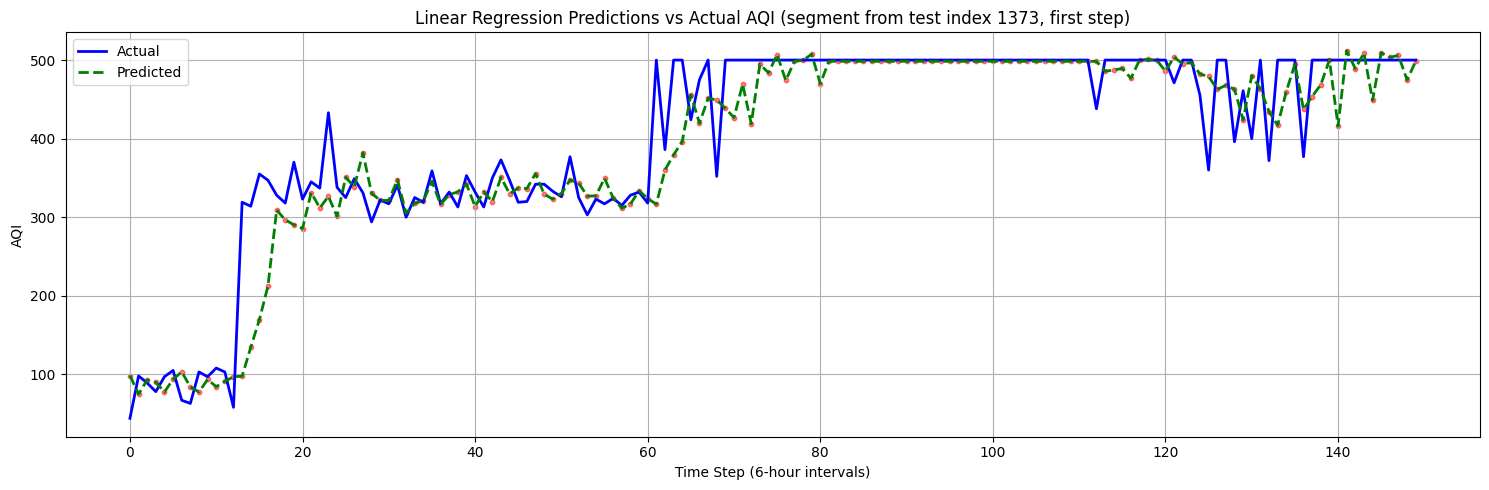

In [ ]:
n_points = 150  # number of sequential points to visualize
start_idx = np.random.randint(0, len(y_test_orig) - n_points)  # random start

# Select continuous segment (first step of multi-step target)
y_true_segment = y_test_orig[start_idx:start_idx + n_points, 0]   # actual
lg_pred_segment = y_test_pred[start_idx:start_idx + n_points, 0]  # predicted

# --------------------------
# Plot
# --------------------------
plt.figure(figsize=(15,5))
plt.plot(range(n_points), y_true_segment, label='Actual', color='blue', linewidth=2)
plt.plot(range(n_points), lg_pred_segment, label='Predicted', color='green', linestyle='--', linewidth=2)
plt.scatter(range(n_points), lg_pred_segment, color='red', s=10, alpha=0.5)  # optional scatter

plt.xlabel("Time Step (6-hour intervals)")
plt.ylabel("AQI")
plt.title(f"Linear Regression Predictions vs Actual AQI (segment from test index {start_idx}, first step)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:

# Training XGBoost Regressor
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train_scaled, y_train_scaled)

# Predict on test set
y_test_pred_scaled = xgb_model.predict(X_test_scaled)

# Convert predictions back to original AQI scale
y_test_pred  = scaler_y.inverse_transform(y_test_pred_scaled)
y_test_orig  = scaler_y.inverse_transform(y_test_scaled)

# Compute test metrics
xgb_mse  = mean_squared_error(y_test_orig, y_test_pred)
xgb_rmse = np.sqrt(xgb_mse)
xgb_mae  = np.mean(np.abs(y_test_orig - y_test_pred))
xgb_r2   = r2_score(y_test_orig, y_test_pred)



print( "                        ╔══════════════════════════════════════════╗")
print( "                        ║        XGBOOST REGRESSION METRICS        ║")
print( "                        ╠══════════════════════════════════════════╣")
print(f"                        ║  RMSE: {xgb_rmse:>30.6f}    ║")
print( "                        ╠══════════════════════════════════════════╣")
print(f"                        ║  MSE:  {xgb_mse:>30.6f}    ║")
print( "                        ╠══════════════════════════════════════════╣")
print(f"                        ║  MAE:  {xgb_mae:>30.6f}    ║")
print( "                        ╠══════════════════════════════════════════╣")
print(f"                        ║  R²:   {xgb_r2:>30.6f}    ║")
print( "                        ╚══════════════════════════════════════════╝")

                        ╔══════════════════════════════════════════╗
                        ║        XGBOOST REGRESSION METRICS        ║
                        ╠══════════════════════════════════════════╣
                        ║  RMSE:                      34.390666    ║
                        ╠══════════════════════════════════════════╣
                        ║  MSE:                     1182.717896    ║
                        ╠══════════════════════════════════════════╣
                        ║  MAE:                       23.545027    ║
                        ╠══════════════════════════════════════════╣
                        ║  R²:                         0.963603    ║
                        ╚══════════════════════════════════════════╝


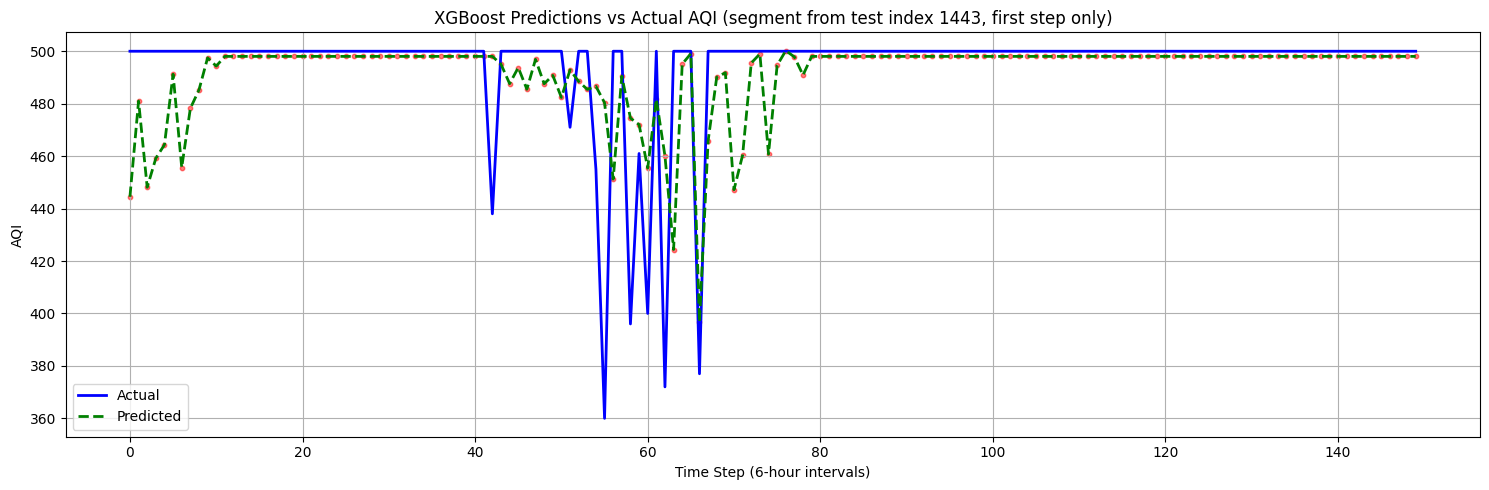

In [ ]:
# Number of points to visualize
n_points = 150

# Random starting index in test set
start_idx = np.random.randint(0, len(y_test_orig) - n_points)

# Choose only the first step of multi-step target for simplicity
y_true_segment = y_test_orig[start_idx:start_idx + n_points, 0]   # first day AQI
xgb_pred_segment = y_test_pred[start_idx:start_idx + n_points, 0]   # first day prediction

plt.figure(figsize=(15,5))
plt.plot(range(n_points), y_true_segment, label='Actual', color='blue', linewidth=2)
plt.plot(range(n_points), xgb_pred_segment, label='Predicted', color='green', linestyle='--', linewidth=2)
plt.scatter(range(n_points), xgb_pred_segment, color='red', s=10, alpha=0.5)

plt.xlabel("Time Step (6-hour intervals)")
plt.ylabel("AQI")
plt.title(f"XGBoost Predictions vs Actual AQI (segment from test index {start_idx}, first step only)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np


rf_model = RandomForestRegressor(
    n_estimators=200, max_depth=None, random_state=42, n_jobs=-1
)

# Train on scaled X_train and y_train
rf_model.fit(X_train_scaled, y_train_scaled)

# Predict on test set
rf_y_pred_scaled = rf_model.predict(X_test_scaled)

# Inverse transform predictions to original AQI scale
rf_y_pred  = scaler_y.inverse_transform(rf_y_pred_scaled)
y_test_orig  = scaler_y.inverse_transform(y_test_scaled)

# Compute test metrics
rf_mse  = mean_squared_error(y_test_orig, rf_y_pred)
rf_rmse = np.sqrt(rf_mse)
rf_mae  = np.mean(np.abs(y_test_orig - rf_y_pred))
rf_r2   = r2_score(y_test_orig, rf_y_pred)


print( "                        ╔══════════════════════════════════════════╗")
print( "                        ║        RANDOM FOREST EVALUATION METRICS  ║")
print( "                        ╠══════════════════════════════════════════╣")
print(f"                        ║  RMSE: {rf_rmse:>30.6f}    ║")
print( "                        ╠══════════════════════════════════════════╣")
print(f"                        ║  MSE:  {rf_mse:>30.6f}    ║")
print( "                        ╠══════════════════════════════════════════╣")
print(f"                        ║  MAE:  {rf_mae:>30.6f}    ║")
print( "                        ╠══════════════════════════════════════════╣")
print(f"                        ║  R²:   {rf_r2:>30.6f}    ║")
print( "                        ╚══════════════════════════════════════════╝")

                        ╔══════════════════════════════════════════╗
                        ║        RANDOM FOREST EVALUATION METRICS  ║
                        ╠══════════════════════════════════════════╣
                        ║  RMSE:                      34.064206    ║
                        ╠══════════════════════════════════════════╣
                        ║  MSE:                     1160.370152    ║
                        ╠══════════════════════════════════════════╣
                        ║  MAE:                       23.586247    ║
                        ╠══════════════════════════════════════════╣
                        ║  R²:                         0.964290    ║
                        ╚══════════════════════════════════════════╝


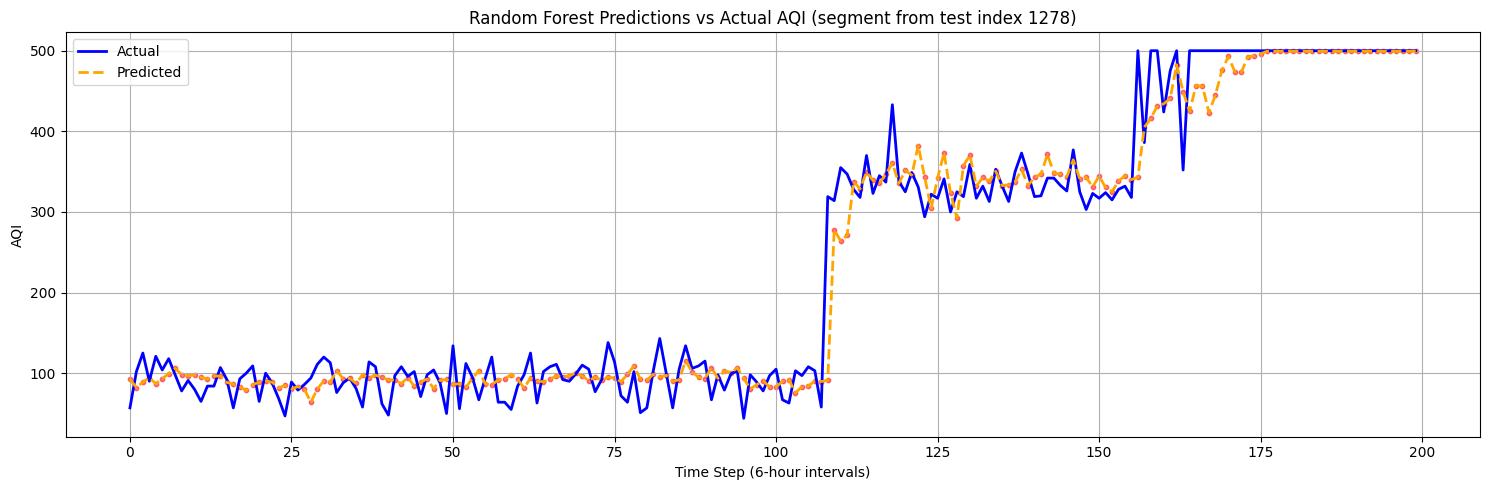

In [ ]:
n_points = 200  # number of sequential points to visualize
start_idx = np.random.randint(0, len(y_test_orig) - n_points)

# Select continuous segment (first step of multi-step target)
y_true_segment = y_test_orig[start_idx:start_idx + n_points, 0]
rf_pred_segment = rf_y_pred[start_idx:start_idx + n_points, 0]


plt.figure(figsize=(15,5))
plt.plot(range(n_points), y_true_segment, label='Actual', color='blue', linewidth=2)
plt.plot(range(n_points), rf_pred_segment, label='Predicted', color='orange', linestyle='--', linewidth=2)
plt.scatter(range(n_points), rf_pred_segment, color='red', s=10, alpha=0.5)  # optional scatter

plt.xlabel("Time Step (6-hour intervals)")
plt.ylabel("AQI")
plt.title(f"Random Forest Predictions vs Actual AQI (segment from test index {start_idx})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

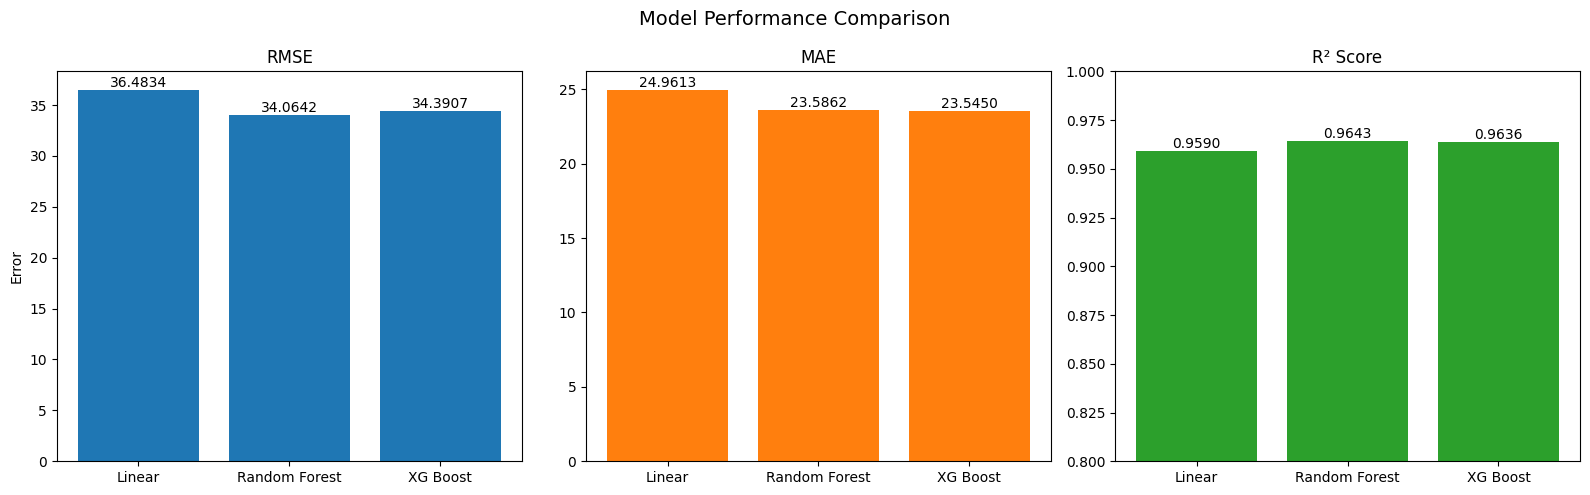

In [ ]:

models = ["Linear", "Random Forest", "XG Boost"]

rmse = [lg_rmse, rf_rmse, xgb_rmse]
mae  = [lg_mae, rf_mae, xgb_mae]
r2   = [lg_r2, rf_r2, xgb_r2]

fig, axes = plt.subplots(1, 3, figsize=(16,5))

def annotate_bars(ax, bars, decimals=4):
    """Add value labels on top of each bar"""
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2,
                height,
                f"{height:.{decimals}f}",
                ha='center', va='bottom', fontsize=10)

# RMSE
bars_rmse = axes[0].bar(models, rmse, color='#1f77b4')  # blue
axes[0].set_title("RMSE")
axes[0].set_ylabel("Error")
annotate_bars(axes[0], bars_rmse)

# MAE
bars_mae = axes[1].bar(models, mae, color='#ff7f0e')  # orange
axes[1].set_title("MAE")
annotate_bars(axes[1], bars_mae)

# R2
bars_r2 = axes[2].bar(models, r2, color='#2ca02c')  # green
axes[2].set_title("R² Score")
axes[2].set_ylim(0.8, 1.0)
annotate_bars(axes[2], bars_r2)

fig.suptitle("Model Performance Comparison", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# Change this date
query_date = "2024-11-10"

target = pd.Timestamp(query_date).date()
test_start = int(len(vikas_sadan_df) * 0.8)
all_dt = vikas_sadan_df['datetime'].values

xgb_full = scaler_y.inverse_transform(xgb_model.predict(X_test_scaled))
lr_full  = scaler_y.inverse_transform(lr_model.predict(X_test_scaled))

rows = []
for i in range(len(y_test_orig)):
    for s in range(look_ahead):
        idx = test_start + i + look_back + s
        if idx >= len(all_dt): continue
        ts = pd.Timestamp(all_dt[idx])
        if ts.date() == target:
            rows.append({
                "Time"    : ts.strftime("%H:%M"),
                "Actual"  : round(float(y_test_orig[i,s]), 2),
                "LR"      : round(float(lr_full[i,s]),     2),
                "XGB"     : round(float(xgb_full[i,s]),    2),
                "RF"      : round(float(rf_y_pred[i,s]),   2),
            })

if not rows:
    print(f"'{query_date}' not in test set. Use a date from the last 20% of data.")
    print(f"Test set starts around: {pd.Timestamp(all_dt[test_start]).date()}")
else:
    df_out = pd.DataFrame(rows).drop_duplicates("Time").sort_values("Time")
    df_out["LR_loss"]  = (df_out["Actual"] - df_out["LR"]).abs().round(2)
    df_out["XGB_loss"] = (df_out["Actual"] - df_out["XGB"]).abs().round(2)
    df_out["RF_loss"]  = (df_out["Actual"] - df_out["RF"]).abs().round(2)
    print(f"\nDate: {query_date}\n")
    print(df_out.to_string(index=False))
    print(f"\nMAE → LR: {df_out.LR_loss.mean():.2f}  XGB: {df_out.XGB_loss.mean():.2f}  RF: {df_out.RF_loss.mean():.2f}")


Date: 2024-11-10

 Time  Actual     LR   XGB     RF  LR_loss  XGB_loss  RF_loss
00:00   500.0 497.59 497.4 499.26     2.41       2.6     0.74
06:00   500.0 497.59 497.4 499.26     2.41       2.6     0.74
12:00   500.0 497.59 497.4 499.26     2.41       2.6     0.74
18:00   500.0 497.59 497.4 499.26     2.41       2.6     0.74

MAE → LR: 2.41  XGB: 2.60  RF: 0.74
